# Philly Winters Are Getting Milder — Or Are They?

Ask anyone who has lived in Philadelphia for more than a decade and they will tell you the winters feel different now. Less biting. Fewer truly miserable stretches. More of those strange 55°F days in January that feel wrong but are welcome anyway.

But feelings are not data. So I went looking for the actual numbers.

Using 20 full winters of Philadelphia daily weather records — from the winter of 2005–06 through 2024–25 — I tracked average temperatures, days where it never climbed above freezing, and total snowfall. The headline finding is that yes, winters are warming. But the full story has a twist that the trend line alone will not show you.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

philly = pd.read_csv("philadelphia_weather_2005_to_2025.csv")
philly['date'] = pd.to_datetime(philly['date'])

# Filter to winter months: December, January, February
winter = philly[philly['month_num'].isin([12, 1, 2])].copy()

# Assign winter season year: Dec 2005 belongs to winter 2005-06, labeled 2006
winter['winter_year'] = winter.apply(
    lambda r: r['year'] + 1 if r['month_num'] == 12 else r['year'], axis=1
)
winter = winter[(winter['winter_year'] >= 2006) & (winter['winter_year'] <= 2025)]

avg_high = winter.groupby('winter_year')['high'].mean().round(2)
freeze_days = winter[winter['high'] < 32].groupby('winter_year').size().reindex(range(2006, 2026), fill_value=0)
snow_total = winter.groupby('winter_year')['snow'].sum().round(1)

print(f"Average winter high, first 5 seasons (2006–2010): {avg_high[avg_high.index <= 2010].mean():.1f}°F")
print(f"Average winter high, last 5 seasons (2021–2025): {avg_high[avg_high.index >= 2021].mean():.1f}°F")
print(f"Change: +{avg_high[avg_high.index >= 2021].mean() - avg_high[avg_high.index <= 2010].mean():.1f}°F")
print(f"Most snow in a single winter: {snow_total.max()}\" ({snow_total.idxmax()}-{snow_total.idxmax()-1999:02d})")
print(f"Least snow in a single winter: {snow_total.min()}\" ({snow_total.idxmin()}-{snow_total.idxmin()-1999:02d})")

Average winter high, first 5 seasons (2006–2010): 43.1°F
Average winter high, last 5 seasons (2021–2025): 45.7°F
Change: +2.6°F
Most snow in a single winter: 78.7" (2010-11)
Least snow in a single winter: 0.3" (2020-21)


## The Trend Is Real: Winters Are Warming

The chart below shows the average daily high temperature for each winter from 2006 through 2025. The trend line slopes upward at roughly 0.17°F per year — modest on its own, but across two decades that adds up to nearly 3°F warmer winters on average.

The last five winters averaged a high of 45.7°F, compared to 43.1°F for the first five. That gap is real and consistent with what people feel when they say winters are "not as bad as they used to be."

But look closely at the individual bars, and the story gets messier.

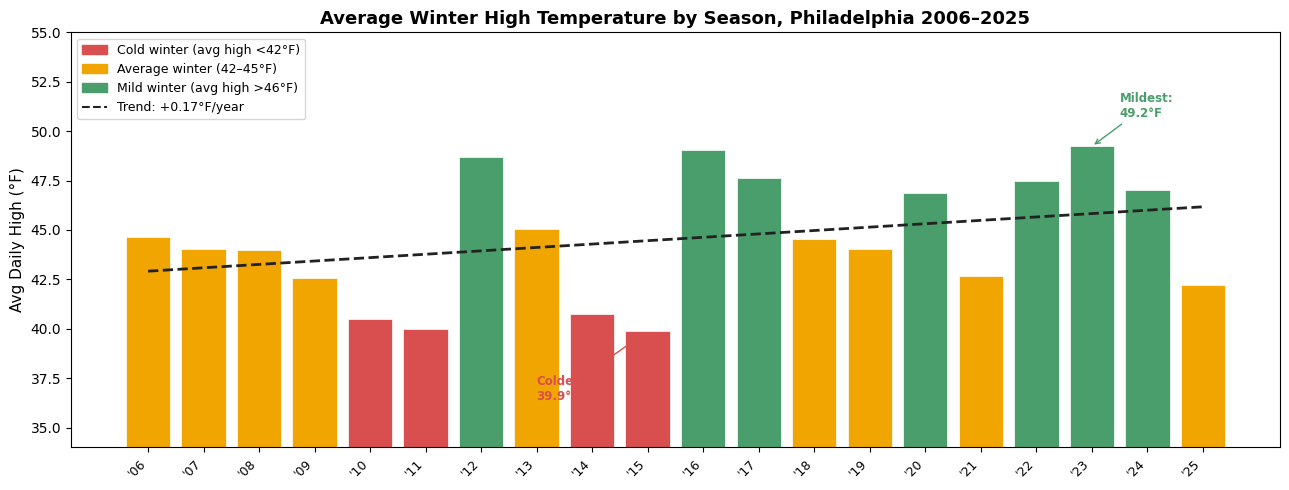

In [9]:
years = avg_high.index.tolist()
x = np.arange(len(years))

# Trend line
slope, intercept = np.polyfit(x, avg_high.values, 1)
trend = slope * x + intercept

colors = ['#d94f4f' if v < 42 else '#f0a500' if v < 46 else '#4a9e6b' for v in avg_high.values]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x, avg_high.values, color=colors, edgecolor='white', linewidth=0.5, zorder=2)
ax.plot(x, trend, color='#222222', linewidth=2, linestyle='--', label=f'Trend: +{slope:.2f}°F/year', zorder=3)

# Annotate coldest and warmest winters
cold_i = avg_high.values.argmin()
warm_i = avg_high.values.argmax()
ax.annotate(f"Coldest:\n{avg_high.values[cold_i]:.1f}°F",
            xy=(x[cold_i], avg_high.values[cold_i]),
            xytext=(x[cold_i] - 2, avg_high.values[cold_i] - 3.5),
            fontsize=8.5, color='#d94f4f', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d94f4f'))
ax.annotate(f"Mildest:\n{avg_high.values[warm_i]:.1f}°F",
            xy=(x[warm_i], avg_high.values[warm_i]),
            xytext=(x[warm_i] + 0.5, avg_high.values[warm_i] + 1.5),
            fontsize=8.5, color='#4a9e6b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#4a9e6b'))

cold_p = mpatches.Patch(color='#d94f4f', label='Cold winter (avg high <42°F)')
ok_p = mpatches.Patch(color='#f0a500', label='Average winter (42–45°F)')
mild_p = mpatches.Patch(color='#4a9e6b', label='Mild winter (avg high >46°F)')
ax.legend(handles=[cold_p, ok_p, mild_p, plt.Line2D([0],[0], color='#222222', linestyle='--', label=f'Trend: +{slope:.2f}°F/year')],
          loc='upper left', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"'{str(y)[2:]}" for y in years], rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Avg Daily High (°F)", fontsize=11)
ax.set_title("Average Winter High Temperature by Season, Philadelphia 2006–2025", fontsize=13, fontweight='bold')
ax.set_ylim(34, 55)
plt.tight_layout()
plt.show()

## The Twist: The Brutal Winters Never Went Away

Here is what the trend line hides.

Even as the overall average drifted upward, Philadelphia still had winters that would make you question every life choice that led you here. The winter of 2009–10 dumped nearly 79 inches of snow on the city — the most in these 20 years by a wide margin. Winter 2013–14 had 20 days where the temperature never broke 32°F. And 2025 came in colder than most of the 2010s.

Meanwhile, winter 2019–20 managed just 0.3 inches of snow all season, and 2023 tied for the mildest average high in the dataset.

The pattern is not steady warming. It is wild swings with a slightly higher floor.

NameError: name 'x' is not defined

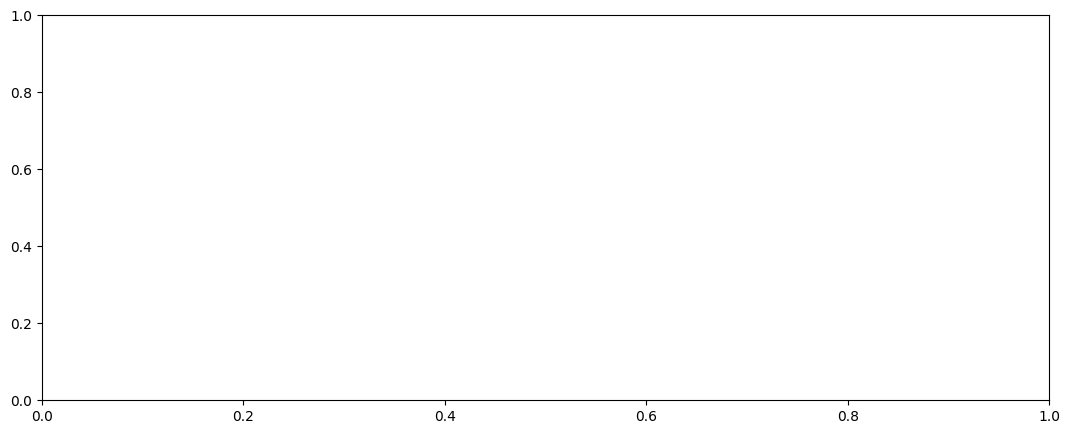

In [3]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(x, snow_total.values, color='#7aaed4', alpha=0.8, label='Total snowfall (inches)', zorder=2)
ax2 = ax1.twinx()
ax2.plot(x, freeze_days.values, color='#d94f4f', linewidth=2.2, marker='o', markersize=5,
         label='Days with high <32°F', zorder=3)

# Annotate the two monster winters
ax1.annotate("78.7\" snow",
             xy=(x[years.index(2010)], snow_total[2010]),
             xytext=(x[years.index(2010)] - 2.5, 65),
             fontsize=8.5, color='#2a6a9a', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2a6a9a'))
ax1.annotate("59.5\" snow",
             xy=(x[years.index(2014)], snow_total[2014]),
             xytext=(x[years.index(2014)] + 0.5, 50),
             fontsize=8.5, color='#2a6a9a', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2a6a9a'))
ax2.annotate("20 freeze days",
             xy=(x[years.index(2014)], freeze_days[2014]),
             xytext=(x[years.index(2014)] + 1, 18),
             fontsize=8.5, color='#d94f4f', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#d94f4f'))

ax1.set_xticks(x)
ax1.set_xticklabels([f"'{str(y)[2:]}" for y in years], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel("Total Snowfall (inches)", fontsize=11, color='#2a6a9a')
ax2.set_ylabel("Days With High Below 32°F", fontsize=11, color='#d94f4f')
ax1.set_title("Snowfall and Freeze Days Per Winter, Philadelphia 2006–2025", fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Mild Winters Are More Common — But Not Guaranteed

The final chart puts it plainly. In the first decade of this dataset, cold winters outnumbered mild ones. In the second decade, that flipped. But even in the milder era, the data occasionally reminds you that Philly winters have not been fully tamed.

The number of days per winter that stayed below freezing all day has declined on average — from about 9 in the early 2010s to around 6 in recent years. That is a real improvement. But 2014 and 2025 both pushed back hard against that trend.

In [4]:
# Split into decade-style halves for comparison
first_half = avg_high[avg_high.index <= 2015]
second_half = avg_high[avg_high.index >= 2016]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, data, label, col in zip(
    axes,
    [first_half, second_half],
    ['2006–2015 (First Decade)', '2016–2025 (Second Decade)'],
    ['#5a8ab5', '#4a9e6b']
):
    colors_half = ['#d94f4f' if v < 42 else '#f0a500' if v < 46 else col for v in data.values]
    ax.bar(data.index, data.values, color=colors_half, edgecolor='white', linewidth=0.5)
    ax.axhline(data.mean(), color='#222', linestyle='--', linewidth=1.3,
               label=f'Avg: {data.mean():.1f}°F')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel("Winter season ending", fontsize=10)
    ax.set_xticks(data.index)
    ax.set_xticklabels([f"'{str(y)[2:]}" for y in data.index], rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.set_ylim(34, 55)

axes[0].set_ylabel("Avg Daily High (°F)", fontsize=11)
fig.suptitle("Philly Winter Avg High: First Decade vs Second Decade", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

NameError: name 'avg_high' is not defined

## Conclusion

So are Philadelphia winters getting milder? The honest answer is: mostly yes, but do not bet on it.

The data shows a genuine upward trend in winter temperatures over 20 years. Mild winters are more common than they used to be, snowfall totals have come down on average, and days where the thermometer never breaks freezing are fewer than they were in the early 2010s.

But the city still throws punches. The winter of 2009–10 buried Philadelphia under nearly 79 inches of snow. The winter of 2013–14 delivered 20 days that never rose above freezing. And 2025 was colder than most of the decade that preceded it.

The real story is not that winters have become reliably mild. It is that the floor has risen — the worst winters are less frequent — but the ceiling on how bad a winter can still get has barely moved at all. Philly winters are not tamed. They are just better behaved on average.